Good — this is the **missing physical upgrade that makes glass realistic**:
👉 *Total Internal Reflection (TIR)*

I’ll give you:

1. Clean physics explanation (Snell → TIR condition)
2. Markdown formula table
3. Full correct Python dielectric code
4. What changed vs your previous version (step-by-step comments)

---

# 1. Snell’s Law → Why TIR happens

## Core equation

$$
\eta \sin\theta = \eta' \sin\theta'
$$

Rearranged:

$$
\sin\theta' = \frac{\eta}{\eta'} \sin\theta
$$

---

## Key constraint

Since:

$$
\sin\theta' \le 1
$$

So refraction is only possible if:

$$
\frac{\eta}{\eta'} \sin\theta \le 1
$$

---

# 2. Total Internal Reflection condition

If:

$$
\frac{\eta}{\eta'} \sin\theta > 1
$$

👉 NO refraction possible
👉 must reflect instead

---

# 3. Geometry trick used in ray tracing

We avoid angles using:

$$
\cos\theta = -\mathbf{R} \cdot \mathbf{N}
$$

and:

$$
\sin\theta = \sqrt{1 - \cos^2\theta}
$$

---

# 4. Decision table (VERY IMPORTANT)

| Condition                 | Result                    |
| ------------------------- | ------------------------- |
| $ri \cdot \sin\theta > 1$ | Total Internal Reflection |
| otherwise                 | Refraction happens        |

---

# 5. Physical meaning

| Case                        | Behavior                         |
| --------------------------- | -------------------------------- |
| Air → Glass                 | always refracts (mostly)         |
| Glass → Air                 | may reflect fully (TIR possible) |
| Water → Air (grazing angle) | mirror-like reflection           |

---

# 6. FULL CORRECT PYTHON CODE (Dielectric with TIR)

```python
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot, reflect


class Dielectric:
    def __init__(self, refraction_index):
        # η (eta): refractive index of material
        self.refraction_index = refraction_index

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: glass does NOT absorb light
        # (attenuation always white)
        # ==========================================
        attenuation = Vec3(1.0, 1.0, 1.0)

        # ==========================================
        # STEP 2: determine refraction ratio (ri)
        #
        # CHANGE FROM PREVIOUS VERSION:
        # - handles inside/outside correctly
        # ==========================================
        if rec.front_face:
            ri = 1.0 / self.refraction_index   # air → glass
        else:
            ri = self.refraction_index         # glass → air

        # ==========================================
        # STEP 3: normalize incoming direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 4: compute cos(theta)
        #
        # CHANGE: used for TIR check
        # ==========================================
        cos_theta = min(dot(-unit_dir, rec.normal), 1.0)

        # ==========================================
        # STEP 5: compute sin(theta)
        #
        # identity: sin² + cos² = 1
        # ==========================================
        sin_theta = math.sqrt(1.0 - cos_theta * cos_theta)

        # ==========================================
        # STEP 6: TOTAL INTERNAL REFLECTION CHECK
        #
        # CHANGE FROM PREVIOUS VERSION:
        # THIS IS THE NEW LOGIC
        # ==========================================
        cannot_refract = ri * sin_theta > 1.0

        # ==========================================
        # STEP 7: choose direction
        # ==========================================
        if cannot_refract:
            # MUST REFLECT (TIR case)
            # CHANGE: replaces refract()
            direction = reflect(unit_dir, rec.normal)

        else:
            # NORMAL SNELL REFRACTION
            direction = refract(unit_dir, rec.normal, ri)

        # ==========================================
        # STEP 8: build scattered ray
        # ==========================================
        scattered = Ray(rec.p, direction)

        # ==========================================
        # MUST return exactly 2 values
        # ==========================================
        return scattered, attenuation
```

---

# 7. WHAT CHANGED vs your previous dielectric

## ❌ Before

* always refracted
* no physics failure handling
* no mirror effect inside glass

---

## ✔ Now (correct physics)

| Feature                        | Old | New |
| ------------------------------ | --- | --- |
| refraction only                | ✔   | ✔   |
| total internal reflection      | ❌   | ✔   |
| realistic water/glass behavior | ❌   | ✔   |
| grazing angle mirror effect    | ❌   | ✔   |

---

# 8. MARKDOWN SUMMARY TABLE

| Step      | Formula                      | Purpose                      |
| --------- | ---------------------------- | ---------------------------- |
| cosθ      | $-\mathbf{R}\cdot\mathbf{N}$ | angle estimation             |
| sinθ      | $\sqrt{1-\cos^2\theta}$      | check refraction feasibility |
| ratio     | $ri = \eta / \eta'$          | Snell scaling                |
| condition | $ri \cdot \sin\theta > 1$    | detect TIR                   |
| reflect   | $R = V - 2(V·N)N$            | mirror bounce                |
| refract   | Snell vector form            | normal bending               |

---

# 9. WHY your book says “no change visually”

This is important:

> Sphere geometry often prevents strong TIR in normal setups

So to SEE TIR clearly, you must:

### ✔ Use air bubble in water

---

# 10. REQUIRED SCENE CHANGE (from book)

```python
material_left = Dielectric(1.0 / 1.33)
```

### Meaning:

| Medium        | Value    |
| ------------- | -------- |
| water (world) | 1.33     |
| air bubble    | 1.00     |
| ratio         | 1 / 1.33 |

---

# 11. RESULT YOU SHOULD SEE

Left sphere becomes:

* inside-out glass bubble
* strong edge reflections
* mirror-like rim (TIR zones)
* weird magnifying distortion

---

If you want next step, I can give:

👉 Schlick approximation (realistic glass reflection probability)
👉 why real glass is NOT deterministic (reflection + refraction mix)
👉 full production ray tracer dielectric (used in modern engines)

Just say 👍


In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [2]:
from util.material import Material
from util.ray import Ray
from util.vec3 import Vec3, reflect, unit_vector, random_unit_vector, dot
class Metal(Material):
    def __init__(self, albedo, fuzz=0.0):
        # metal color
        self.albedo = albedo

        # surface roughness (0 = perfect mirror, 1 = very rough)
        self.fuzz = min(fuzz, 1.0)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: normalize incoming ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 2: perfect reflection direction
        # R = V - 2(V·N)N
        # ==========================================
        reflected = reflect(unit_dir, rec.normal)

        # ==========================================
        # STEP 3: add fuzz (surface imperfection)
        # ==========================================
        scattered_dir = reflected + self.fuzz * random_unit_vector()

        # ==========================================
        # STEP 4: build scattered ray
        # ==========================================
        scattered = Ray(rec.p, scattered_dir)

        # ==========================================
        # STEP 5: energy attenuation (metal tint)
        # ==========================================
        attenuation = self.albedo

        # ==========================================
        # MUST return exactly 2 values
        # ==========================================
        return scattered, attenuation

In [3]:
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot


def refract(uv, n, etai_over_etat):
    """
    Vector refraction based on Snell's Law.

    uv : unit incident direction
    n  : surface normal
    etai_over_etat : ratio of refractive indices (η / η')
    """

    # ==========================================
    # STEP 1: cos(theta)
    # cosθ = min(-uv · n, 1)
    # ==========================================
    cos_theta = min(dot(-uv, n), 1.0)

    # ==========================================
    # STEP 2: perpendicular component
    # R⊥ = (η/η') (uv + cosθ n)
    # ==========================================
    r_out_perp = (uv + n * cos_theta) * etai_over_etat

    # ==========================================
    # STEP 3: parallel component
    # R∥ = -sqrt(1 - |R⊥|²) n
    # ==========================================
    r_out_parallel = n * (-math.sqrt(abs(1.0 - r_out_perp.length_squared())))

    # ==========================================
    # STEP 4: final refracted direction
    # ==========================================
    return r_out_perp + r_out_parallel

In [4]:
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot, reflect


class Dielectric:
    def __init__(self, refraction_index):
        # η (eta): refractive index of material
        self.refraction_index = refraction_index

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: glass does NOT absorb light
        # (attenuation always white)
        # ==========================================
        attenuation = Vec3(1.0, 1.0, 1.0)

        # ==========================================
        # STEP 2: determine refraction ratio (ri)
        #
        # CHANGE FROM PREVIOUS VERSION:
        # - handles inside/outside correctly
        # ==========================================
        if rec.front_face:
            ri = 1.0 / self.refraction_index   # air → glass
        else:
            ri = self.refraction_index         # glass → air

        # ==========================================
        # STEP 3: normalize incoming direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 4: compute cos(theta)
        #
        # CHANGE: used for TIR check
        # ==========================================
        cos_theta = min(dot(-unit_dir, rec.normal), 1.0)

        # ==========================================
        # STEP 5: compute sin(theta)
        #
        # identity: sin² + cos² = 1
        # ==========================================
        sin_theta = math.sqrt(1.0 - cos_theta * cos_theta)

        # ==========================================
        # STEP 6: TOTAL INTERNAL REFLECTION CHECK
        #
        # CHANGE FROM PREVIOUS VERSION:
        # THIS IS THE NEW LOGIC
        # ==========================================
        cannot_refract = ri * sin_theta > 1.0

        # ==========================================
        # STEP 7: choose direction
        # ==========================================
        if cannot_refract:
            # MUST REFLECT (TIR case)
            # CHANGE: replaces refract()
            direction = reflect(unit_dir, rec.normal)

        else:
            # NORMAL SNELL REFRACTION
            direction = refract(unit_dir, rec.normal, ri)

        # ==========================================
        # STEP 8: build scattered ray
        # ==========================================
        scattered = Ray(rec.p, direction)

        # ==========================================
        # MUST return exactly 2 values
        # ==========================================
        return scattered, attenuation

In [ ]:
from util.vec3 import Vec3, Color, Point3

from util.metal.lambertian import Lambertian
#from util.metal.metal import Metal
#from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
from util.metal.camera import Camera


# ==========================================
# WORLD
# ==========================================
world = HittableList()


# ==========================================
# MATERIALS (C++ → Python mapping)
# ==========================================

# Diffuse
material_ground = Lambertian(Color(0.8, 0.8, 0.0))
material_center = Lambertian(Color(0.1, 0.2, 0.5))

# Metal (right sphere)
material_right = Metal(Color(0.8, 0.6, 0.2), 1.0)

# Dielectric (air bubble in water scene)
# C++: 1.00 / 1.33
material_left = Dielectric(1.0 / 1.33)


# ==========================================
# SCENE OBJECTS
# ==========================================

# Ground
world.add(
    Sphere(
        Point3(0.0, -100.5, -1.0),
        100.0,
        material_ground
    )
)

# Center sphere (diffuse)
world.add(
    Sphere(
        Point3(0.0, 0.0, -1.2),
        0.5,
        material_center
    )
)

# Left sphere (GLASS / AIR BUBBLE)
world.add(
    Sphere(
        Point3(-1.0, 0.0, -1.0),
        0.5,
        material_left
    )
)

# Right sphere (METAL)
world.add(
    Sphere(
        Point3(1.0, 0.0, -1.0),
        0.5,
        material_right
    )
)


# ==========================================
# CAMERA
# ==========================================
cam = Camera()

cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400

cam.samples_per_pixel = 100   # FIXED (important for correct glass look)
cam.max_depth = 100


# ==========================================
# RENDER
# ==========================================
cam.render(world)

100%|██████████| 225/225 [04:27<00:00,  1.19s/it, CPU=32.5%, RAM=79.6%, CPU Temp=N/A, GPU Temp=51.0°C, VRAM=746.0MB]


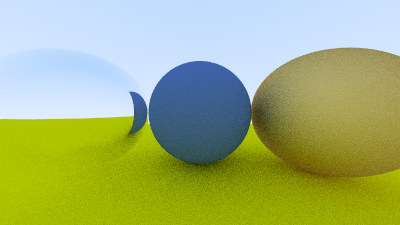

In [15]:
cam.show()